In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- Global plot style settings for the report ---
# Times New Roman is a licensed Microsoft font and is usually NOT installed on
# Linux/Colab machines. If it's missing, matplotlib silently substitutes a
# default font (that's the "Times New Roman error" / silent fallback).
# This block explicitly checks for it and, if unavailable, falls back to
# Liberation Serif -- a free font that is metrically identical to Times New
# Roman (same character widths/shape), so the plots still look correct.
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_preferred = ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'DejaVu Serif']
FONT_FAMILY = next((f for f in _preferred if f in _available_fonts), 'serif')
print(f"Using font family for plots: {FONT_FAMILY}")

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelweight'] = 'bold'   # bold x/y axis LABELS
plt.rcParams['axes.titleweight'] = 'bold'   # bold plot titles
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.format'] = 'eps'


def bold_ticks(ax=None):
    """Bold the x and y tick numbers/labels on the given axis (rcParams can't do this)."""
    if ax is None:
        ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontfamily(FONT_FAMILY)


def bold_legend(ax=None, legend_obj=None):
    """Bold the legend text on the given axis, or on an explicit legend object."""
    leg = legend_obj
    if leg is None:
        ax = ax if ax is not None else plt.gca()
        leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontweight('bold')
            text.set_fontfamily(FONT_FAMILY)


Using font family for plots: Liberation Serif


In [3]:
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/267/banknote+authentication.zip"
column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

try:
    df = pd.read_csv(url, header=None, names=column_names)
    print("--- Data Loaded via read_csv (UCI URL) ---")
except Exception as e:
    # Fallback for restricted-network environments: use the local CSV copy instead
    df = pd.read_csv("data_banknote_authentication.csv", header=None, names=column_names)
    print("--- UCI URL unreachable, loaded local data_banknote_authentication.csv instead ---")


--- UCI URL unreachable, loaded local data_banknote_authentication.csv instead ---


In [4]:
print("--- 1st five rows ---\n",df.head())
print("\n--- DIMENSIONS --- \n",df.shape)
print("\n--- Missing Values Check ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---\n")
print(df.describe())

--- 1st five rows ---
    variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

--- DIMENSIONS --- 
 (1372, 5)

--- Missing Values Check ---
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

--- Descriptive Statistics ---

          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.82

In [5]:
# === TASK 2 ===
y = df["class"]
X = df.drop("class", axis=1)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


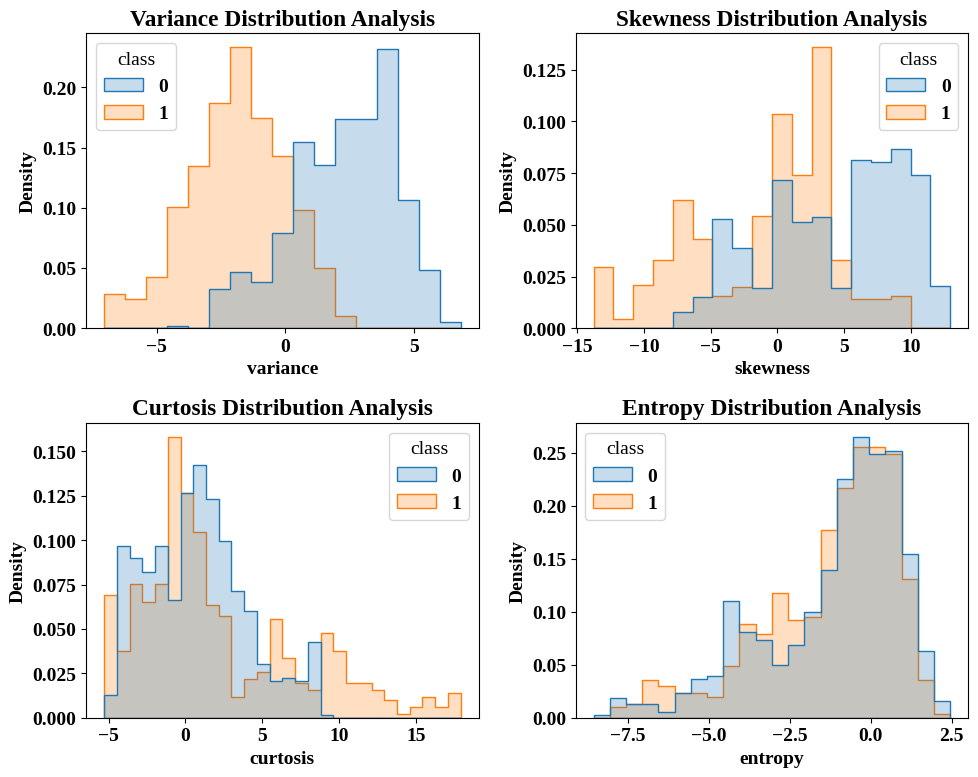

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure 'class' is mapped back to 0 and 1 or text labels
# Split the grid into 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, feature in enumerate(column_names[:-1]): # Iterate only over the first 4 features
    row, col = i // 2, i % 2

    sns.histplot(
        ax=axes[row, col],
        data=df,
        x=feature,
        hue="class",
        element="step",
        stat="density",
        common_norm=False,
    )
    axes[row, col].set_title(f"{feature.capitalize()} Distribution Analysis")
    bold_ticks(axes[row, col])
    bold_legend(axes[row, col])

plt.tight_layout()
plt.savefig('feature_histogram.eps', dpi=600, bbox_inches='tight')
plt.show()


It is clear from the histogram plots that variance is the only symmetric and uniform distribution, with noticeable separation between the 2 classes. Curtosis and Entropy are extremely skewed and hence have extreme outlier values. The skewness distribution isnt as skewed as curtosis or entropy but still is slightly negatively skewed.

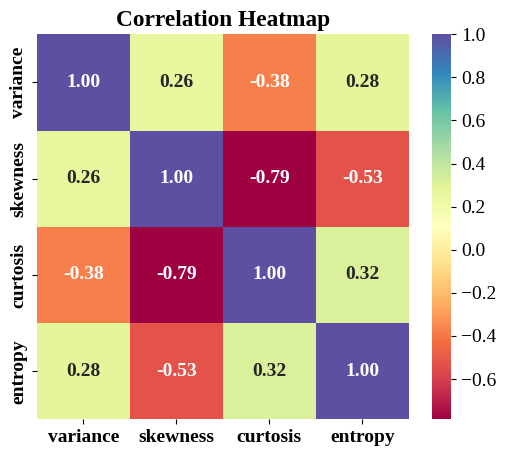

In [7]:
# --- Correlation Heatmap: shows linear relationship between every pair of features ---
plt.figure(figsize=(6, 5))
ax = sns.heatmap(X.corr(), annot=True, cmap='Spectral', fmt='.2f')
plt.title("Correlation Heatmap")
bold_ticks(ax)
# bold the annotation numbers inside the cells too
for text in ax.texts:
    text.set_fontweight('bold')
    text.set_fontfamily(FONT_FAMILY)
plt.savefig('correlation_heatmap.eps', dpi=600, bbox_inches='tight')
plt.show()


Skewness and Curtosis are highly negatively correlated meaning curtosis decreases as skewness increases. At the same time there is a significant amount of negative correlation between skewness and entropy too.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


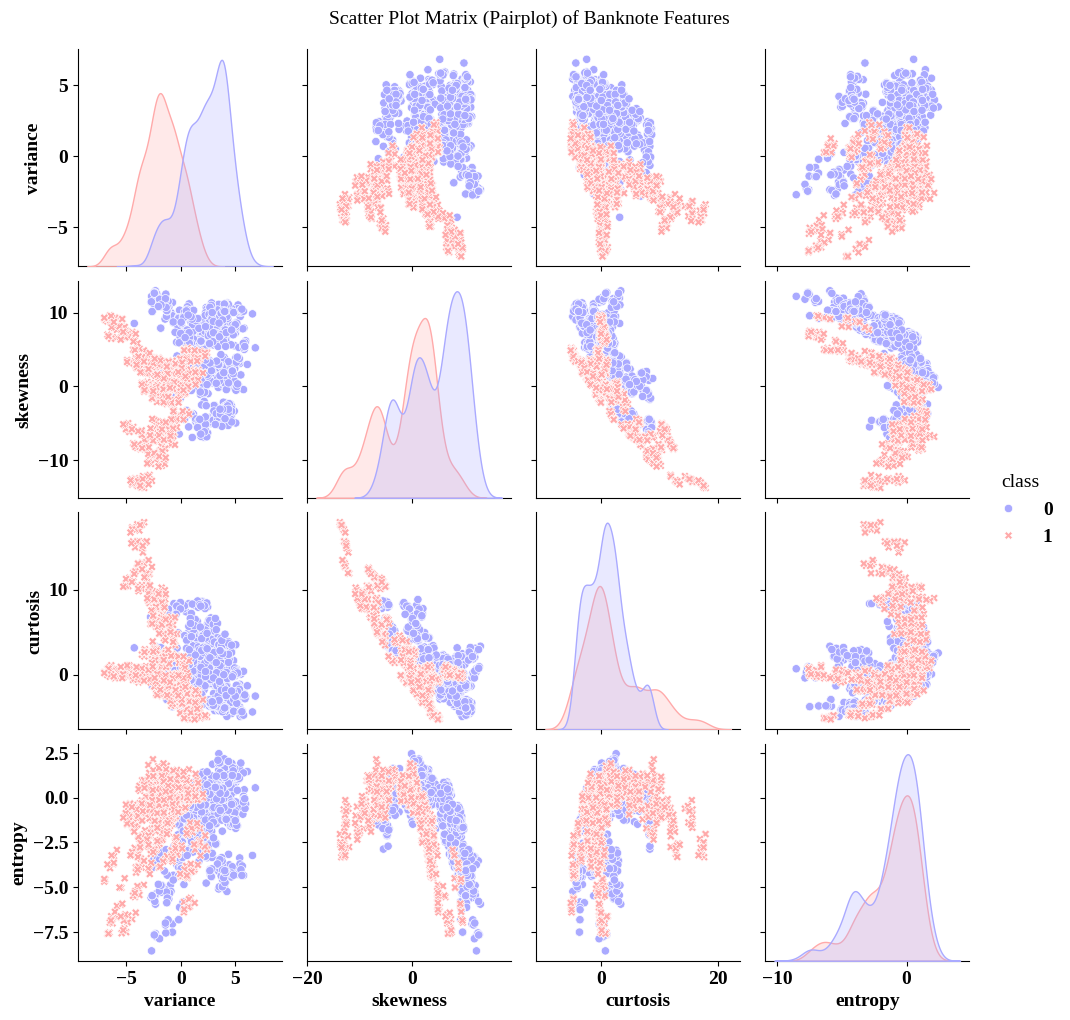

In [8]:
grid = sns.pairplot(df, hue="class", palette="bwr", markers=["o", "X"], diag_kind="kde")

grid.fig.suptitle("Scatter Plot Matrix (Pairplot) of Banknote Features", y=1.02, fontsize=14)

# Bold every subplot's tick labels
for ax in grid.axes.flat:
    if ax is not None:
        bold_ticks(ax)

# Bold the shared legend (pairplot puts it on the figure, not a single axis)
if grid._legend is not None:
    bold_legend(legend_obj=grid._legend)

grid.fig.savefig('scatter_plot.eps', dpi=600, bbox_inches='tight')
plt.show()


All the pair plots have been generated in 4x4 matrix, each color-separated by the class labels. Most of the scatter plots have less overlap between both classes, while some have almost none. Hence we can conclude that the data is linearly separable !

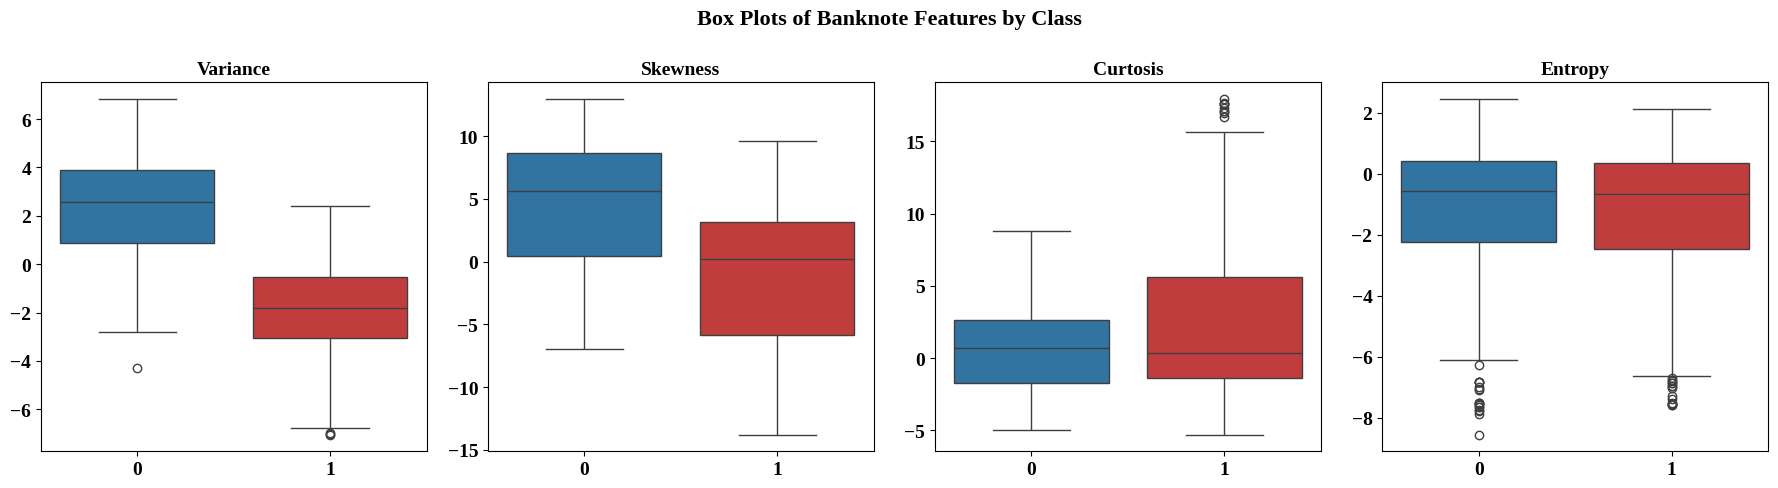

In [9]:
# 2. Set up the matplotlib figure grid (1 row, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle(
    "Box Plots of Banknote Features by Class", fontsize=16, fontweight="bold"
)

# List of features to loop through
features = ["variance", "skewness", "curtosis", "entropy"]
colors = ["#1f77b4", "#d62728"]

# 3. Loop through features and create a boxplot for each
for i, feature in enumerate(features):
    sns.boxplot(
        ax=axes[i],
        x="class",
        y=feature,
        data=df,
        hue="class",
        palette=colors,
        legend=False,
    )
    axes[i].set_title(feature.capitalize(), fontsize=14)
    axes[i].set_xlabel("")  # Hide x-label to keep it clean
    axes[i].set_ylabel("")  # Hide y-label since title shows the feature name
    bold_ticks(axes[i])

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.savefig('boxplots.eps', dpi=600, bbox_inches='tight')
plt.show()


There is no overlapping between genuine and forged notes when it comes to variances while skewness has somewhat of an overlap. However the notes cannot be separated by looking at curtosis and entropy as both classes have almost full overlap in both features.

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
norm_scaler = MinMaxScaler()
X_normalized = pd.DataFrame(norm_scaler.fit_transform(X), columns=X.columns)

print("\n--- Normalized Features (Z-score) ---")
print(X_normalized.head())
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


--- Normalized Features (Z-score) ---
   variance  skewness  curtosis   entropy
0  0.769004  0.839643  0.106783  0.736628
1  0.835659  0.820982  0.121804  0.644326
2  0.786629  0.416648  0.310608  0.786951
3  0.757105  0.871699  0.054921  0.450440
4  0.531578  0.348662  0.424662  0.687362
Training samples: 1097
Testing samples : 275


In [11]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50):
        # Weight Initialization: start all weights at zero (simple, standard choice)
        self.weights = np.zeros(n_features)
        # Bias Initialization: start bias at zero
        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs

        # History logs, one entry per epoch, used for plotting later
        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

    def step_activation(self, z):
        # Step Activation Function: outputs 1 if z >= 0, else 0
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        # Forward Propagation: weighted sum followed by the step activation
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0

            # Perceptron Learning Rule: update weights sample-by-sample (online learning)
            for xi, yi in zip(X, y):
                y_hat = self.forward(xi)
                error = yi - y_hat

                if error != 0:
                    misclassified += 1
                    # Weight Update Rule: w_new = w_old + eta * (y - y_hat) * x
                    self.weights += self.lr * error * xi
                    # Bias Update Rule: b_new = b_old + eta * (y - y_hat)
                    self.bias += self.lr * error

            # Log this epoch's state for later plotting/tables
            self.errors_history.append(misclassified)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            if verbose:
                print(f"Epoch {epoch:2d} | Misclassified: {misclassified:3d} "
                      f"| Weights: {np.round(self.weights, 3)} | Bias: {self.bias:.3f}")

            # Early stop if the model has fully converged (no errors this epoch)
            if misclassified == 0:
                if verbose:
                    print(f"Converged at epoch {epoch}.")
                break

    def predict(self, X):
        return self.forward(X)


In [12]:
model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=50)
# Pass the underlying NumPy arrays to the fit method to ensure correct iteration over data rows
model.fit(X_train.values, y_train.values)

Epoch  1 | Misclassified: 166 | Weights: [-0.068 -0.039 -0.053  0.015] | Bias: 0.080
Epoch  2 | Misclassified:  88 | Weights: [-0.083 -0.061 -0.077  0.012] | Bias: 0.100
Epoch  3 | Misclassified:  57 | Weights: [-0.087 -0.066 -0.096  0.015] | Bias: 0.110
Epoch  4 | Misclassified:  51 | Weights: [-0.095 -0.08  -0.093  0.01 ] | Bias: 0.120
Epoch  5 | Misclassified:  47 | Weights: [-0.098 -0.086 -0.1    0.006] | Bias: 0.130
Epoch  6 | Misclassified:  45 | Weights: [-0.106 -0.089 -0.101  0.004] | Bias: 0.140
Epoch  7 | Misclassified:  48 | Weights: [-0.112 -0.099 -0.108  0.009] | Bias: 0.140
Epoch  8 | Misclassified:  32 | Weights: [-0.118 -0.101 -0.116  0.01 ] | Bias: 0.140
Epoch  9 | Misclassified:  19 | Weights: [-0.115 -0.101 -0.116  0.013] | Bias: 0.150
Epoch 10 | Misclassified:  40 | Weights: [-0.123 -0.105 -0.121  0.01 ] | Bias: 0.150
Epoch 11 | Misclassified:  35 | Weights: [-0.122 -0.111 -0.121  0.014] | Bias: 0.160
Epoch 12 | Misclassified:  28 | Weights: [-0.127 -0.112 -0.126  0

Epoch 41 | Misclassified:  20 | Weights: [-0.172 -0.174 -0.188  0.012] | Bias: 0.220
Epoch 42 | Misclassified:  25 | Weights: [-0.167 -0.168 -0.194  0.003] | Bias: 0.230
Epoch 43 | Misclassified:  22 | Weights: [-0.172 -0.17  -0.195 -0.   ] | Bias: 0.230
Epoch 44 | Misclassified:  22 | Weights: [-0.172 -0.176 -0.195  0.006] | Bias: 0.230
Epoch 45 | Misclassified:  20 | Weights: [-0.171 -0.176 -0.201  0.008] | Bias: 0.230
Epoch 46 | Misclassified:  18 | Weights: [-0.175 -0.18  -0.199  0.007] | Bias: 0.230
Epoch 47 | Misclassified:  23 | Weights: [-0.174 -0.178 -0.196  0.004] | Bias: 0.240


Epoch 48 | Misclassified:  26 | Weights: [-0.182 -0.182 -0.194  0.005] | Bias: 0.240
Epoch 49 | Misclassified:  22 | Weights: [-0.185 -0.183 -0.196  0.004] | Bias: 0.240
Epoch 50 | Misclassified:  20 | Weights: [-0.181 -0.18  -0.208  0.006] | Bias: 0.240


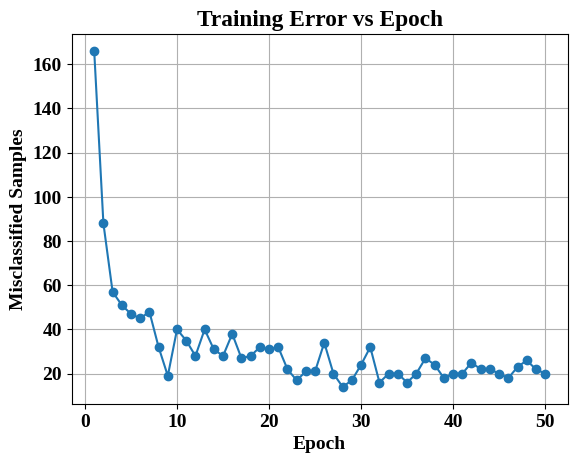

In [13]:
# --- Training Error vs Epoch ---
fig, ax = plt.subplots()
ax.plot(range(1, len(model.errors_history) + 1), model.errors_history, marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified Samples")
ax.set_title("Training Error vs Epoch")
ax.grid(True)
bold_ticks(ax)
plt.savefig('training_error.eps', dpi=600, bbox_inches='tight')
plt.show()


We observe the error (misclassified samples) reduce drastically after the first few epochs. The error of the perceptron later "stabilized" when about 30 epochs had been reached.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


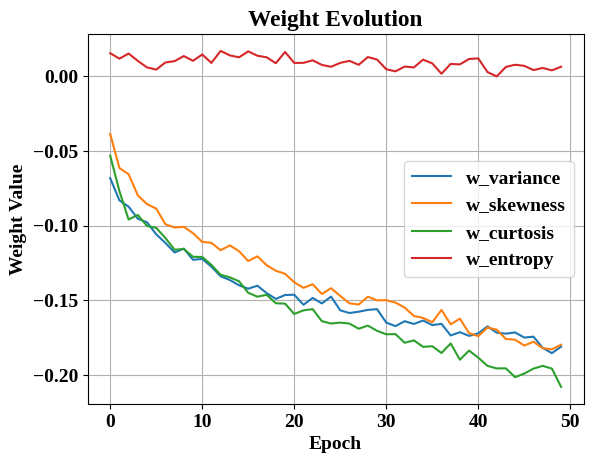

In [14]:
# --- Weight Evolution  ---
weights_arr = np.array(model.weights_history)
fig, ax = plt.subplots()
for i, col in enumerate(features):
    ax.plot(weights_arr[:, i], label=f'w_{col}')
ax.set_xlabel("Epoch")
ax.set_ylabel("Weight Value")
ax.set_title("Weight Evolution")
ax.legend()
ax.grid(True)
bold_ticks(ax)
bold_legend(ax)
plt.savefig('weight_evolution.eps', dpi=600, bbox_inches='tight')
plt.show()


Weight values changed abruptly during the initial epochs. However the weight values later flatline when our model was able to find a good enough decision boundary between the target classes as the epochs grew.

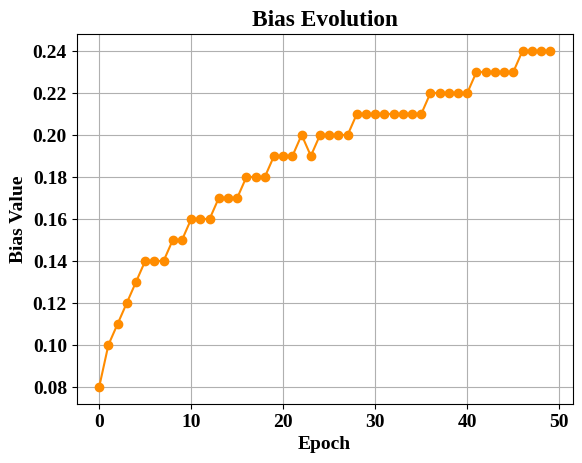

In [15]:
# --- Bias Evolution ---
fig, ax = plt.subplots()
ax.plot(model.bias_history, marker='o', color='darkorange')
ax.set_xlabel("Epoch")
ax.set_ylabel("Bias Value")
ax.set_title("Bias Evolution")
ax.grid(True)
bold_ticks(ax)
plt.savefig('bias_evolution.eps', dpi=600, bbox_inches='tight')
plt.show()


The bias value kept increasing significantly in the inital epochs. In the later epochs the increase wasn't as huge as the intial increase but the values still were constantly rising.

Accuracy : 0.9891
Precision: 1.0000
Recall   : 0.9764
F1-score : 0.9880


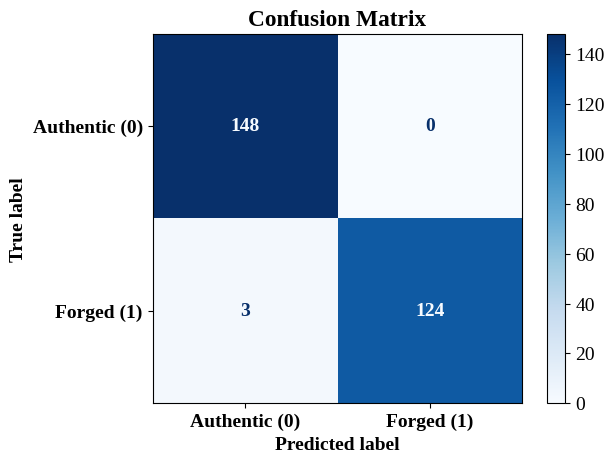

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Authentic (0)', 'Forged (1)']).plot(cmap='Blues')
plt.title("Confusion Matrix")
bold_ticks(disp.ax_)
# bold the count numbers written inside each cell
for text in disp.ax_.texts:
    text.set_fontweight('bold')
    text.set_fontfamily(FONT_FAMILY)
plt.savefig('confusion_matrix.eps', dpi=600, bbox_inches='tight')
plt.show()


Just 3 samples were wrongly classified as authentic bills, hence the slight reduction in accuracy. However all the authentic bills were predicted correctly,hence the model has 100% precision.

Learning Rate 0.001  | Epochs to converge:  50 | Test Accuracy: 0.9891
Learning Rate 0.01   | Epochs to converge:  50 | Test Accuracy: 0.9891


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Learning Rate 0.1    | Epochs to converge:  50 | Test Accuracy: 0.9891


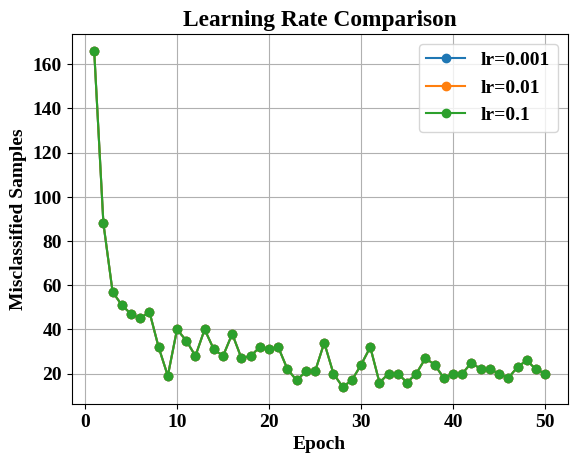

In [17]:
learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50)
    m.fit(X_train.values, y_train.values, verbose=False)   # verbose off here to keep output short
    lr_results[lr] = m.errors_history

    y_pred_lr = m.predict(X_test)
    print(f"Learning Rate {lr:<6} | Epochs to converge: {len(m.errors_history):3d} "
          f"| Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

# --- Learning Rate Comparison plot ---
fig, ax = plt.subplots()
for lr, errors in lr_results.items():
    ax.plot(range(1, len(errors) + 1), errors, marker='o', label=f'lr={lr}')
ax.set_xlabel("Epoch")
ax.set_ylabel("Misclassified Samples")
ax.set_title("Learning Rate Comparison")
ax.legend()
ax.grid(True)
bold_ticks(ax)
bold_legend(ax)
plt.savefig('learning_rate_comparison.eps', dpi=600, bbox_inches='tight')
plt.show()


All the three curves end up on top of eachother. This is because at every epoch the same samples were misclassified as they had the same sign even though they had different learning rates.

In [18]:
from sklearn.linear_model import Perceptron as SklearnPerceptron

sk_model = SklearnPerceptron(max_iter=50, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

print("Scratch Perceptron  Accuracy:", accuracy_score(y_test, y_pred))
print("Sklearn Perceptron  Accuracy:", accuracy_score(y_test, y_pred_sklearn))


Scratch Perceptron  Accuracy: 0.9890909090909091
Sklearn Perceptron  Accuracy: 0.9781818181818182


The manual implementation performed with better accuracy than sklearn's builtin perceptron. This may be because sklearn implements random shuffling of training data and early stopping as well among other minor differences.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


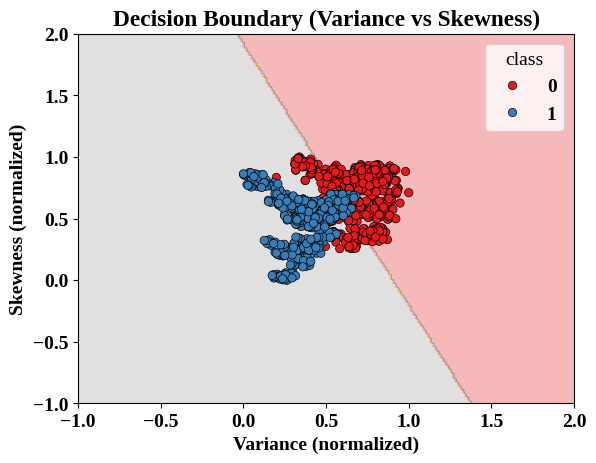

In [19]:
# === OPTIMIZED DECISION BOUNDARY CELL ===
X_2f = X_normalized.iloc[:, [0, 1]]  # variance, skewness
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2f, y, test_size=0.2, random_state=42
)

model_2f = Perceptron(n_features=2, learning_rate=0.01, n_epochs=50)
model_2f.fit(X2_train.values, y2_train.values, verbose=False)

# Create a mesh grid covering the feature space
x_min, x_max = X_2f.iloc[:, 0].min() - 1, X_2f.iloc[:, 0].max() + 1
y_min, y_max = X_2f.iloc[:, 1].min() - 1, X_2f.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_preds = model_2f.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Render the plot
fig, ax = plt.subplots()
ax.contourf(xx, yy, grid_preds, alpha=0.3, cmap="Set1")
sns.scatterplot(
    x=X_2f.iloc[:, 0], y=X_2f.iloc[:, 1], hue=y, palette="Set1", edgecolor="k", ax=ax
)
ax.set_xlabel("Variance (normalized)")
ax.set_ylabel("Skewness (normalized)")
ax.set_title("Decision Boundary (Variance vs Skewness)")
bold_ticks(ax)
bold_legend(ax)
plt.savefig('decision_boundary.eps', dpi=600, bbox_inches='tight')
plt.show()
